In [45]:
# Some parts of the code have been assisted by Google Gemini via basic Google search.
# I read through documentation before blindly trusting an AI answer.

In [46]:
import pandas as pd
import geopandas as gpd
from shapely import Point, LineString, Polygon

In [47]:
def point(csv_data:str)-> gpd.GeoDataFrame:
    """
    Converts a csv file of latitude and longitude coordinates into Point geometries in a GeoDataFrame.
    
    Parameters:
    -----------
    csv_data : str
        File path containing latitude and longitude coordinates in the first two columns.
        Does not include headers.
    
    Returns:
    --------
    gdf : geopandas.GeoDataFrame
        Point geometries in a GeoDataFrame corresponding to the latitude and longitude coordinates in the csv file.
        In the coordinate system EPSG:4326.
    """
    gdf = pd.read_csv(csv_data, header=None)

    geometry = []
    for lat, lon in zip(gdf[0],gdf[1]):
        if lat > 90 or lon > 180:
            if lat > 90:
                lat = 90
            if lon > 180:
                lon = 180
        if lat < -90 or lon < -180:
            if lat < -180:
                lat = -90
            if lon < -180:
                lon = -180
        geometry.append(Point(lon, lat))

    gdf.columns = gdf.columns.astype(str)

    gdf = gpd.GeoDataFrame(gdf, geometry=geometry, crs="EPSG:4326")

    return gdf

In [48]:
point(r"C:\Users\thewe\Downloads\bradford_lls.csv")

,0,1,geometry
0,34.700683,-86.777698,POINT (-86.7777 34.70068)
1,34.701943,-86.777440,POINT (-86.77744 34.70194)
2,34.702703,-86.777131,POINT (-86.77713 34.7027)
3,34.703143,-86.776859,POINT (-86.77686 34.70314)
4,34.703581,-86.777032,POINT (-86.77703 34.70358)
5,34.704658,-86.776915,POINT (-86.77691 34.70466)
6,34.705215,-86.776740,POINT (-86.77674 34.70521)
7,34.706098,-86.776635,POINT (-86.77664 34.7061)
8,34.706355,-86.776250,POINT (-86.77625 34.70636)
9,34.707146,-86.775721,POINT (-86.77572 34.70715)


<Axes: >

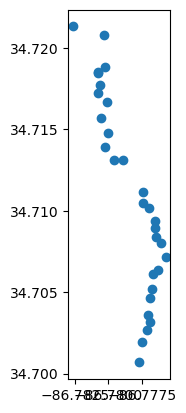

In [49]:
point(r"C:\Users\thewe\Downloads\bradford_lls.csv").plot()

In [50]:
point(r"C:\Users\thewe\Downloads\bradford_lls.csv").to_file(r"C:\Users\thewe\Downloads\bradford_lls_points.shp", driver='ESRI Shapefile')

In [51]:
def line_string(csv_data:str)-> gpd.GeoDataFrame:
    """
    Converts a csv file of latitude and longitude coordinates into Point geometries in a GeoDataFrame.
    
    Parameters:
    -----------
    csv_data : str
        File path containing latitude and longitude coordinates in the first two columns.
        Does not include headers.
    
    Returns:
    --------
    gdf : geopandas.GeoDataFrame
        Point geometries in a GeoDataFrame corresponding to the latitude and longitude coordinates in the csv file.
        In the coordinate system EPSG:4326.
    """
    gdf = pd.read_csv(r"C:\Users\thewe\Downloads\bradford_lls.csv", header=None)

    coords = []
    for lat, lon in zip(gdf[0],gdf[1]):
        if lat > 180 or lon > 180:
            if lat > 180:
                lat = lat - 180
            if lon > 180:
                lon = lon - 180
        if lat < -180 or lon < -180:
            if lat < -180:
                lat = lat + 180
            if lon < -180:
                lon = lon + 180
        coords.append(Point(lon, lat))

    geometry = [LineString(coords)]

    gdf.columns = gdf.columns.astype(str)

    gdf = gpd.GeoDataFrame(gdf.loc[[0]], geometry=geometry, crs="EPSG:4326")

    return gdf

In [52]:
line_string(r"C:\Users\thewe\Downloads\bradford_lls.csv")

,0,1,geometry
0,34.700683,-86.777698,"LINESTRING (-86.7777 34.70068, -86.77744 34.70..."


<Axes: >

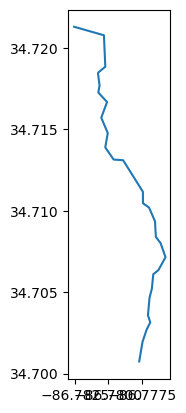

In [53]:
line_string(r"C:\Users\thewe\Downloads\bradford_lls.csv").plot()

In [54]:
line_string(r"C:\Users\thewe\Downloads\bradford_lls.csv").to_file(r"C:\Users\thewe\Downloads\bradford_lls_linestring.shp", driver='ESRI Shapefile')